# 🧠 DyslexiaLens — Dataset Dengan Augmentasi EMNIST

Notebook ini merupakan versi **augmented** dari `Dyslexia_NoAugmentation.ipynb`.
Dataset Gambo asli diperkaya dengan data EMNIST untuk menyeimbangkan kelas Normal vs Disleksia.

**Sumber data:** `Dataset/Gambo_EMNIST/` (Gambo + EMNIST ByClass)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os, re, warnings
from PIL import Image
from collections import defaultdict
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

BASE = 'Dataset/Gambo_EMNIST'
CSV_OUTPUT = 'master_dataset_emnist.csv'
CSV_FINAL = 'master_dataset_emnist_final.csv'

---
# Tahap 3: Pembuatan Master CSV

Membangun `master_dataset_emnist.csv` dari struktur folder `Gambo_EMNIST`.

In [2]:
rows = []
for split in ['Train', 'Test']:
    for category in ['Normal', 'Corrected', 'Reversal']:
        folder = os.path.join(BASE, split, category)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.endswith('.png'):
                continue
            img_path = os.path.join('Dataset', 'Gambo_EMNIST', split, category, fname)
            target = 0 if category == 'Normal' else 1
            # Severity from filename prefix
            prefix = fname.split('_')[0] if '_' in fname else fname.split('-')[0]
            try:
                score = int(prefix) if prefix.isdigit() else 0
            except:
                score = 0
            rows.append({
                'image_path': img_path,
                'file_name': fname,
                'split': split,
                'folder_category': category,
                'severity_score': score,
                'target_class': target
            })

df = pd.DataFrame(rows)
df.to_csv(CSV_OUTPUT, index=False)
print(f'Master CSV: {len(df):,} baris')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi Split:')
print(df['split'].value_counts())
print(f'\nDistribusi Kelas:')
print(df['target_class'].value_counts().rename({0:"Normal",1:"Disleksia"}))

Master CSV: 298,982 baris
Kolom: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class']

Distribusi Split:
split
Train    204311
Test      94671
Name: count, dtype: int64

Distribusi Kelas:
target_class
Normal       149501
Disleksia    149481
Name: count, dtype: int64


---
# Tahap 4: Exploratory Data Analysis (EDA)

### Pertanyaan Bisnis
> *Dapatkah pola goresan tulisan tangan digunakan sebagai indikator awal disleksia?*
> *Seberapa efektif penambahan data EMNIST untuk menyeimbangkan kelas?*

### 4A. Distribusi Kelas per Split

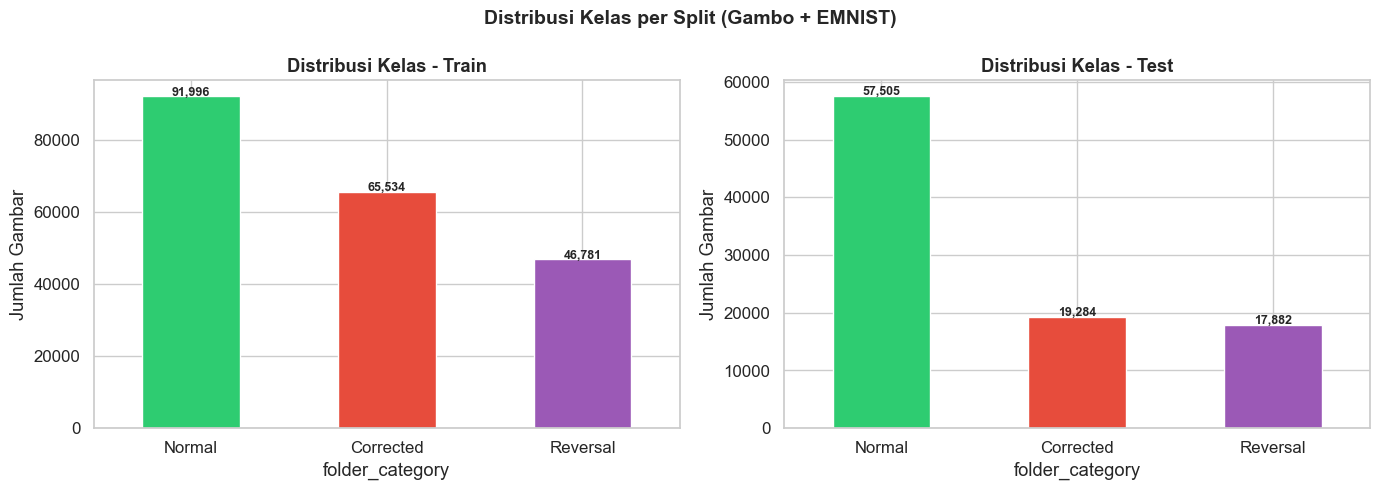

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, split in enumerate(['Train', 'Test']):
    subset = df[df['split'] == split]
    counts = subset['folder_category'].value_counts()
    colors = {'Normal':'#2ecc71','Corrected':'#e74c3c','Reversal':'#9b59b6'}
    bars = counts.plot(kind='bar', ax=axes[idx],
                       color=[colors.get(c,'#95a5a6') for c in counts.index])
    axes[idx].set_title(f'Distribusi Kelas - {split}', fontweight='bold')
    axes[idx].set_ylabel('Jumlah Gambar')
    axes[idx].tick_params(axis='x', rotation=0)
    for bar in bars.patches:
        axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                       f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Distribusi Kelas per Split (Gambo + EMNIST)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/class_distribution_emnist.png', dpi=150, bbox_inches='tight')
plt.show()

### 4B. Distribusi Severity Score

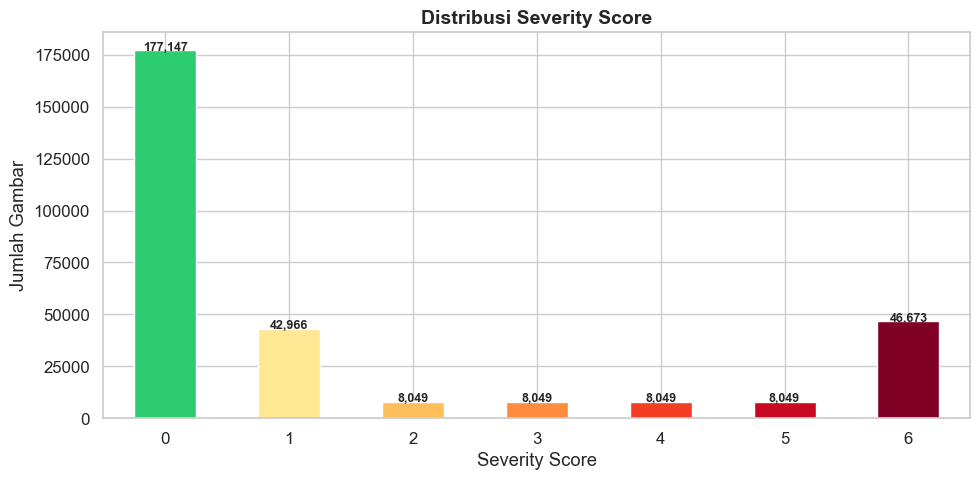

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sev = df['severity_score'].value_counts().sort_index()
colors_sev = ['#2ecc71'] + [plt.cm.YlOrRd(i/6) for i in range(1,7)]
sev.plot(kind='bar', ax=ax, color=colors_sev[:len(sev)])
ax.set_title('Distribusi Severity Score', fontweight='bold', fontsize=14)
ax.set_xlabel('Severity Score')
ax.set_ylabel('Jumlah Gambar')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/severity_distribution_emnist.png', dpi=150, bbox_inches='tight')
plt.show()

### 4C. Sampel Visual: Normal vs Corrected vs Reversal

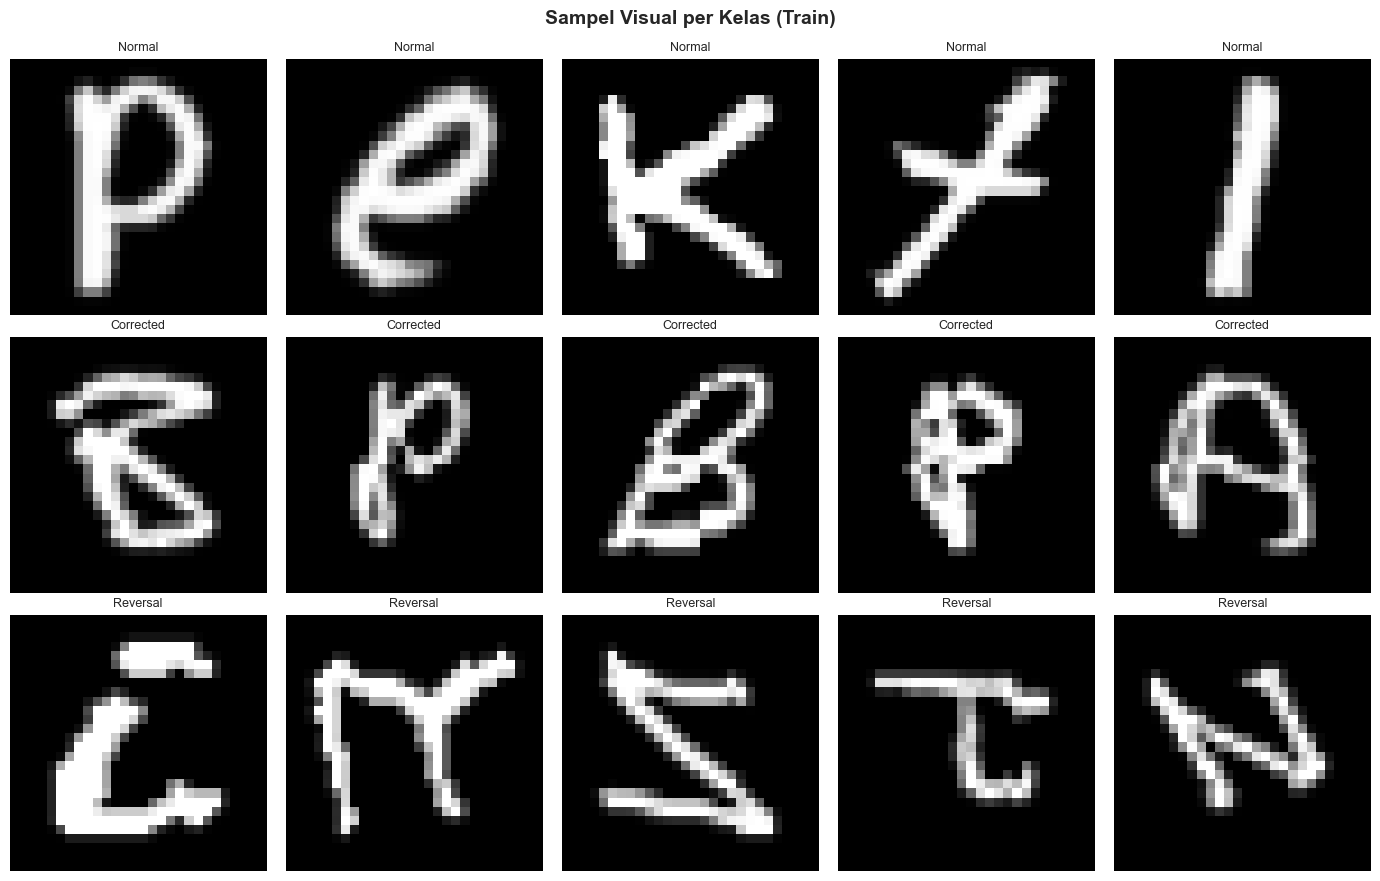

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
categories = ['Normal', 'Corrected', 'Reversal']

for row, cat in enumerate(categories):
    subset = df[(df['folder_category'] == cat) & (df['split'] == 'Train')]
    samples = subset.sample(min(5, len(subset)), random_state=42)
    for col, (_, sample) in enumerate(samples.iterrows()):
        img_path = os.path.join('..', sample['image_path']) if not os.path.exists(sample['image_path']) else sample['image_path']
        try:
            img = Image.open(img_path).convert('L').resize((28,28))
            axes[row][col].imshow(np.array(img), cmap='gray')
        except:
            axes[row][col].text(0.5,0.5,'N/A',ha='center',va='center')
        axes[row][col].set_title(f'{cat}', fontsize=9)
        axes[row][col].axis('off')

plt.suptitle('Sampel Visual per Kelas (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/class_samples_emnist.png', dpi=150, bbox_inches='tight')
plt.show()

### 4D. Sampel Visual per Severity Score

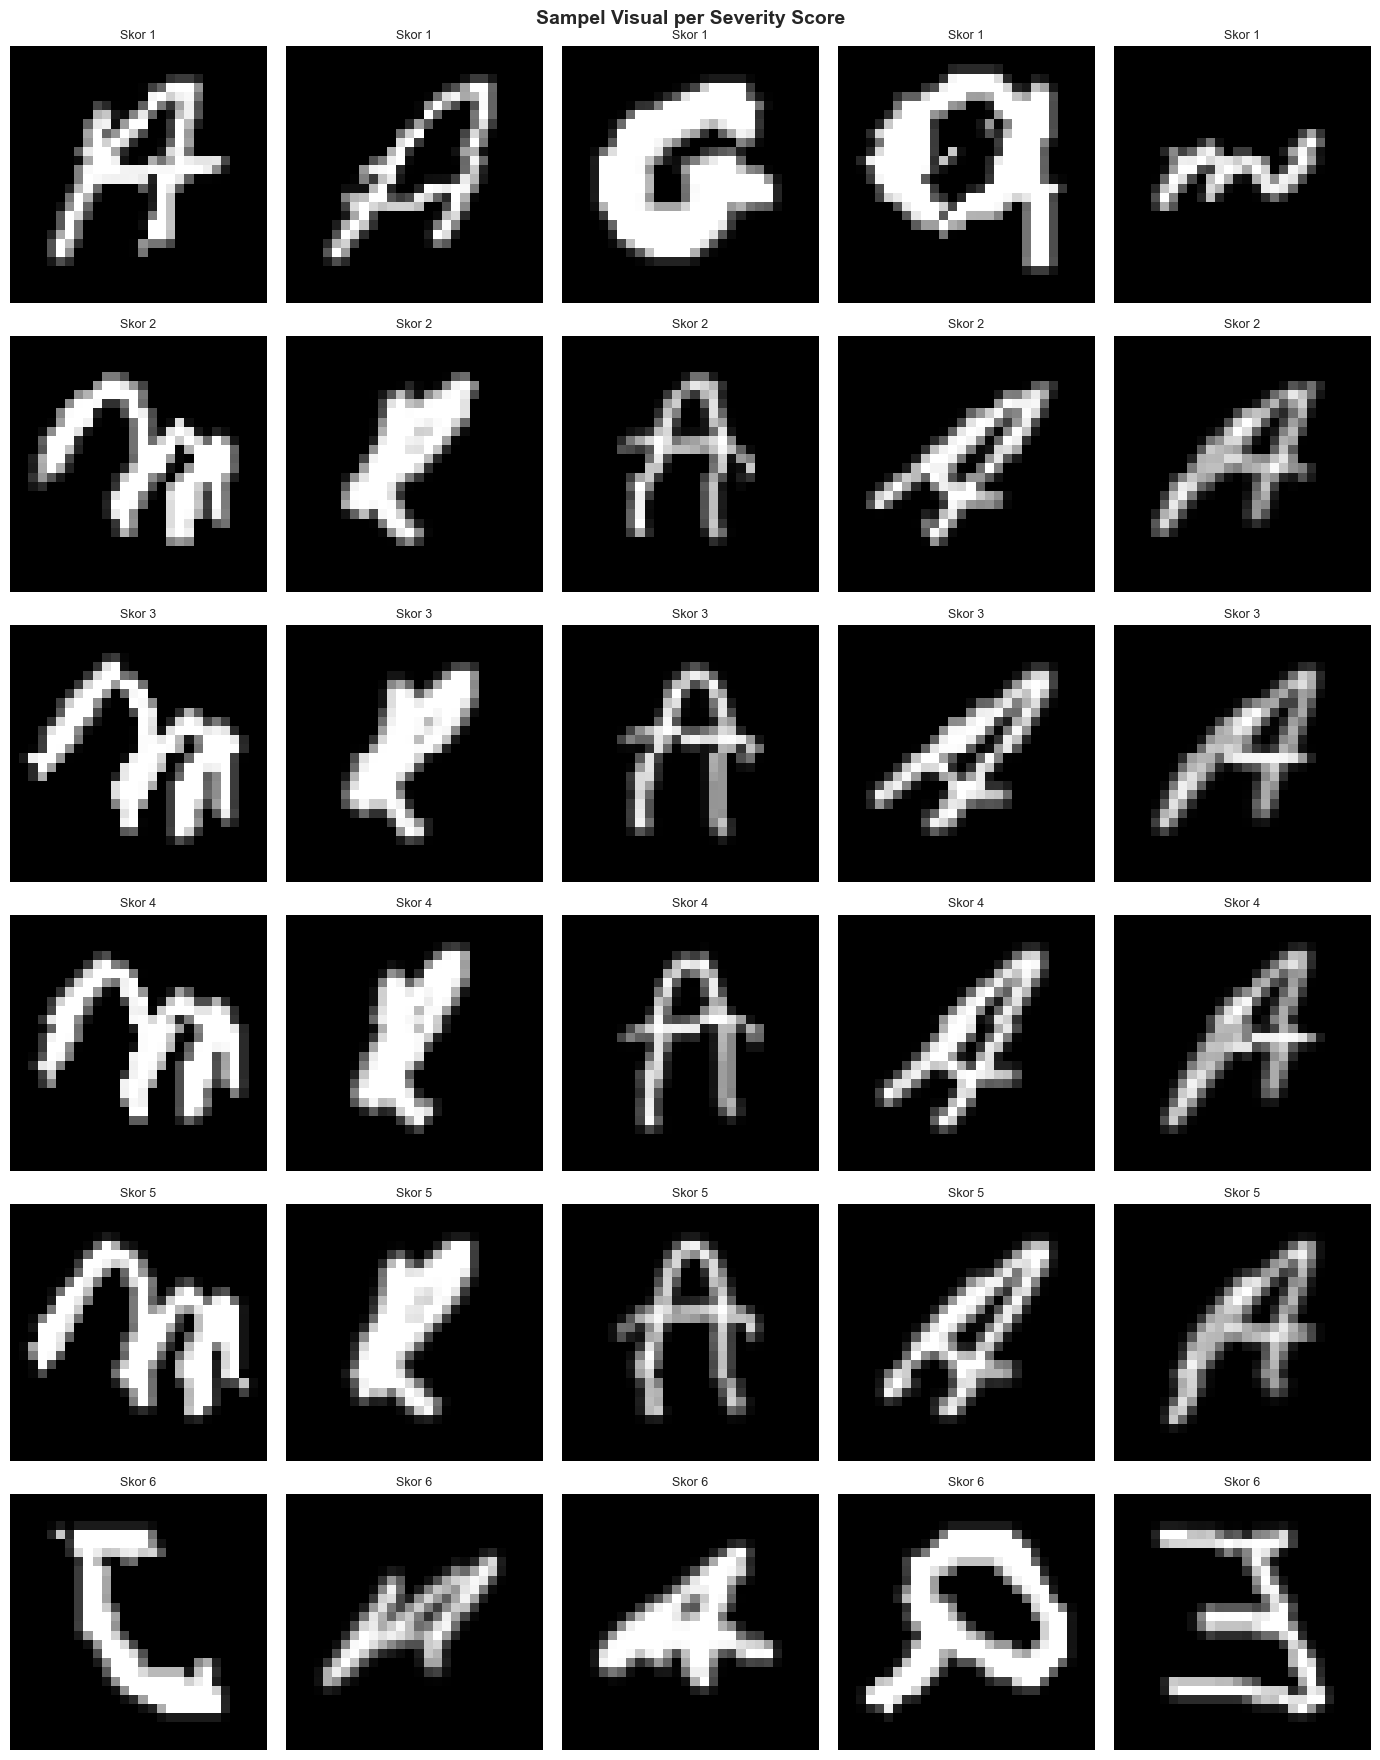

In [7]:
scores = sorted(df[df['severity_score']>0]['severity_score'].unique())
n_scores = len(scores)
if n_scores > 0:
    fig, axes = plt.subplots(n_scores, 5, figsize=(14, 3*n_scores))
    if n_scores == 1: axes = [axes]
    for row, score in enumerate(scores):
        subset = df[df['severity_score'] == score]
        samples = subset.sample(min(5, len(subset)), random_state=42)
        for col, (_, s) in enumerate(samples.iterrows()):
            img_path = os.path.join('..', s['image_path']) if not os.path.exists(s['image_path']) else s['image_path']
            try:
                img = Image.open(img_path).convert('L').resize((28,28))
                axes[row][col].imshow(np.array(img), cmap='gray')
            except:
                axes[row][col].text(0.5,0.5,'N/A',ha='center',va='center')
            axes[row][col].set_title(f'Skor {score}', fontsize=9)
            axes[row][col].axis('off')
    plt.suptitle('Sampel Visual per Severity Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../assets/severity_samples_emnist.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4E. Heatmap Rata-rata Piksel (Skor Terendah vs Tertinggi)

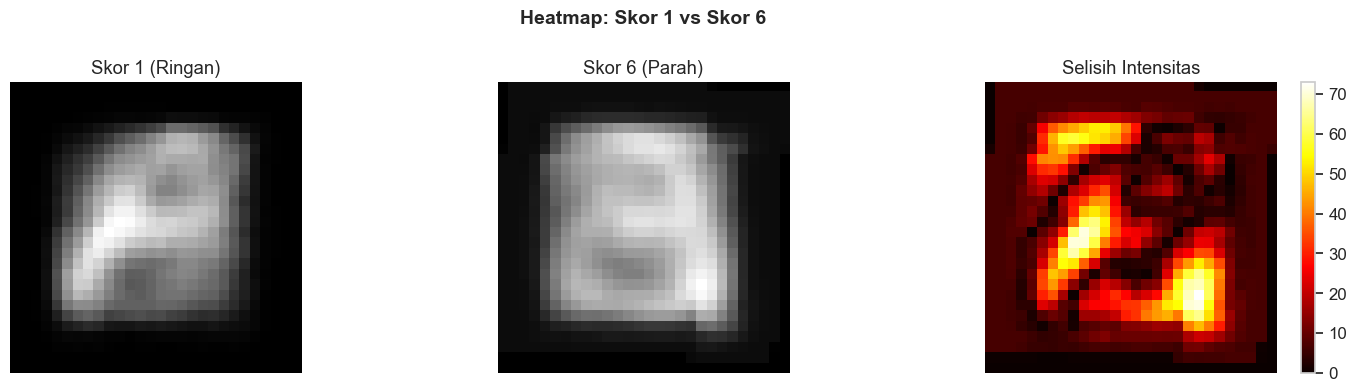

Rata-rata selisih intensitas: 14.00


In [8]:
def compute_mean_image(subset, n=500):
    samples = subset.sample(min(n, len(subset)), random_state=42)
    arrays = []
    for _, row in samples.iterrows():
        p = row['image_path']
        if not os.path.exists(p): p = os.path.join('..', p)
        try:
            img = Image.open(p).convert('L').resize((28,28))
            arrays.append(np.array(img, dtype=np.float32))
        except: continue
    return np.mean(arrays, axis=0) if arrays else np.zeros((28,28))

dys = df[df['severity_score'] > 0]
if len(dys) > 0:
    min_s = dys['severity_score'].min()
    max_s = dys['severity_score'].max()
    mean_low = compute_mean_image(dys[dys['severity_score']==min_s])
    mean_high = compute_mean_image(dys[dys['severity_score']==max_s])
    diff = np.abs(mean_high - mean_low)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(mean_low, cmap='gray'); axes[0].set_title(f'Skor {min_s} (Ringan)')
    axes[1].imshow(mean_high, cmap='gray'); axes[1].set_title(f'Skor {max_s} (Parah)')
    im = axes[2].imshow(diff, cmap='hot'); axes[2].set_title('Selisih Intensitas')
    plt.colorbar(im, ax=axes[2])
    for ax in axes: ax.axis('off')
    plt.suptitle(f'Heatmap: Skor {min_s} vs Skor {max_s}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../assets/heatmap_emnist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Rata-rata selisih intensitas: {np.mean(diff):.2f}')

### 4F. Analisis Keseimbangan Kelas (Impact EMNIST)

Visualisasi perbandingan rasio kelas sebelum dan sesudah penambahan EMNIST.

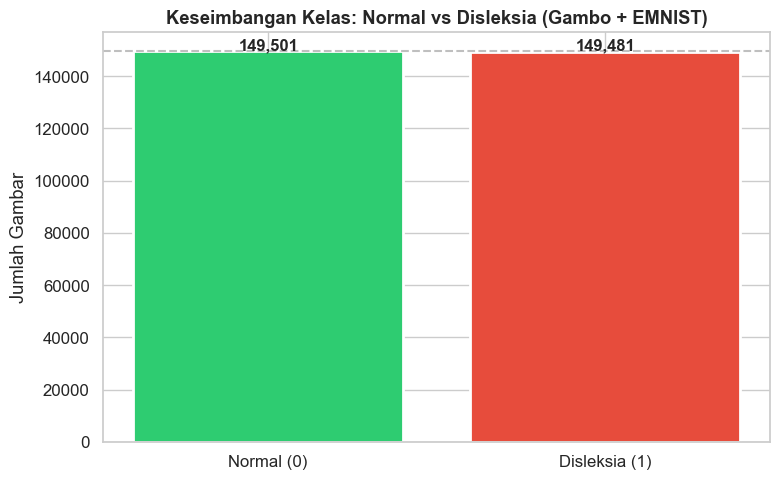

Normal: 149,501 | Disleksia: 149,481 | Rasio 1:1.00


In [9]:
normal_count = len(df[df['target_class']==0])
dys_count = len(df[df['target_class']==1])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Normal (0)', 'Disleksia (1)'], [normal_count, dys_count],
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Keseimbangan Kelas: Normal vs Disleksia (Gambo + EMNIST)', fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
ratio = dys_count/normal_count if normal_count > 0 else 0
ax.axhline(y=normal_count, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f'Normal: {normal_count:,} | Disleksia: {dys_count:,} | Rasio 1:{ratio:.2f}')

### 4G. Karakter Paling Sering Muncul

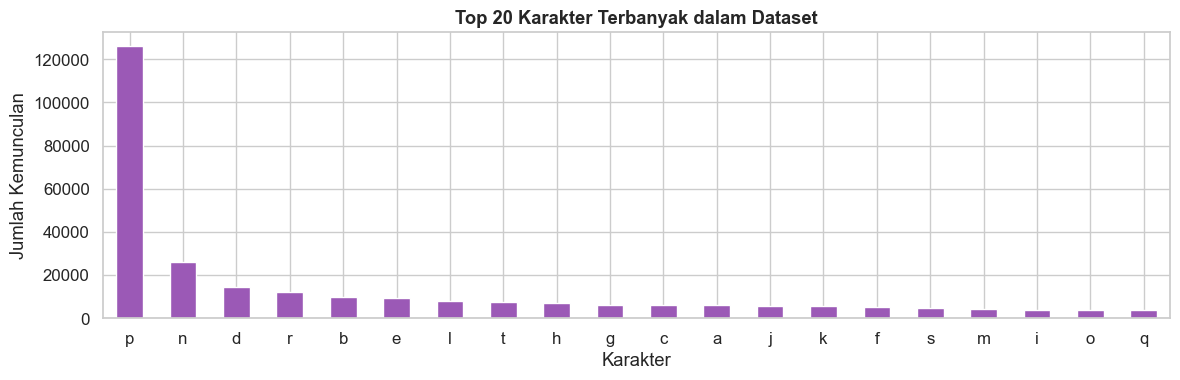

In [10]:
chars = df['file_name'].str.extract(r'([a-zA-Z])')[0].str.lower()
char_counts = chars.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 4))
char_counts.plot(kind='bar', color='#9b59b6', ax=ax)
ax.set_title('Top 20 Karakter Terbanyak dalam Dataset', fontweight='bold')
ax.set_ylabel('Jumlah Kemunculan')
ax.set_xlabel('Karakter')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
# Tahap 5: Stratified Splitting

Membuat split Train/Validation/Test yang stratified.

### 5A. Stratified Split (Train -> Train + Validation)

In [11]:
from sklearn.model_selection import train_test_split

train_df = df[df['split'] == 'Train'].copy()
test_df = df[df['split'] == 'Test'].copy()

# Split Train -> 80% Train + 20% Validation
train_final, val_final = train_test_split(
    train_df, test_size=0.2, random_state=42,
    stratify=train_df['target_class']
)

train_final = train_final.copy()
val_final = val_final.copy()
test_final = test_df.copy()

train_final['split'] = 'Train'
val_final['split'] = 'Validation'
test_final['split'] = 'Test'

df_final = pd.concat([train_final, val_final, test_final], ignore_index=True)
df_final.to_csv(CSV_FINAL, index=False)

print(f'Total: {len(df_final):,}')
for s in ['Train','Validation','Test']:
    n = len(df_final[df_final["split"]==s])
    print(f'  {s:12s}: {n:>8,} ({n/len(df_final)*100:.1f}%)')

Total: 298,982
  Train       :  163,448 (54.7%)
  Validation  :   40,863 (13.7%)
  Test        :   94,671 (31.7%)


### 5B. Class Weights untuk AI Engineer

In [12]:
from sklearn.utils.class_weight import compute_class_weight

binary_classes = np.array([0, 1])
binary_weights = compute_class_weight('balanced', classes=binary_classes, y=train_final['target_class'].values)
binary_weight_dict = dict(zip(binary_classes.astype(int), binary_weights))

print('=== CLASS WEIGHTS ===')
for cls, w in binary_weight_dict.items():
    label = 'Normal' if cls == 0 else 'Disleksia'
    print(f'  Kelas {cls} ({label}): {w:.4f}')

=== CLASS WEIGHTS ===
  Kelas 0 (Normal): 1.1104
  Kelas 1 (Disleksia): 0.9095


### 5C. Validasi Visual Distribusi Split

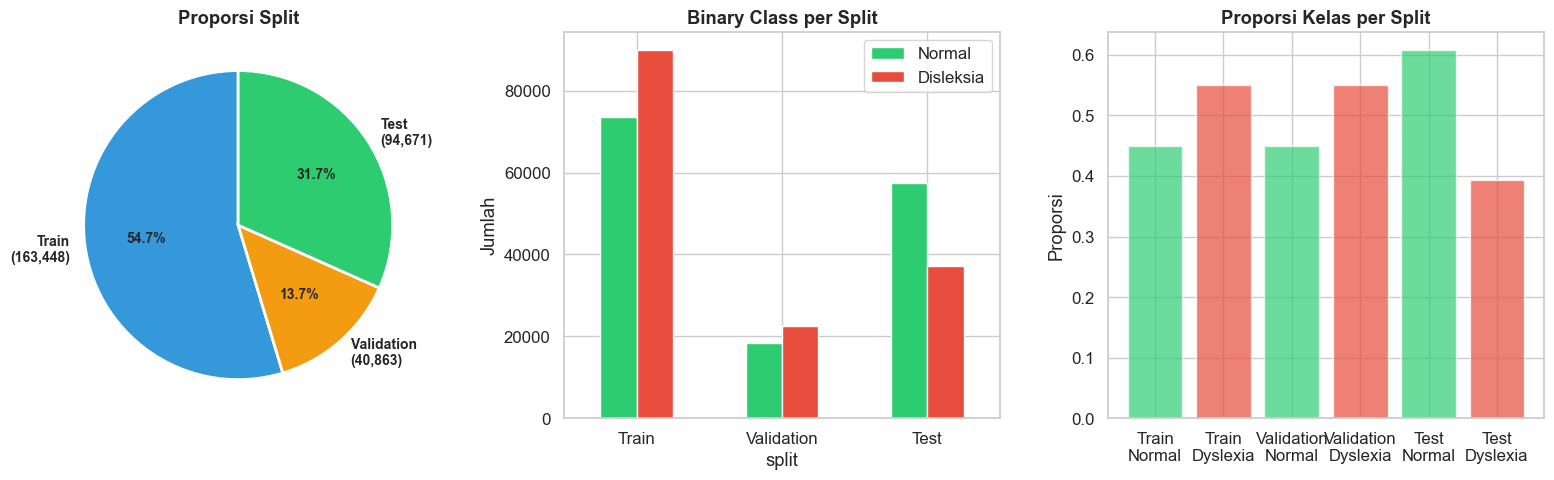

In [13]:
fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
split_sizes = df_final['split'].value_counts().reindex(['Train','Validation','Test'])
ax1.pie(split_sizes, labels=[f'{s}\n({v:,})' for s,v in split_sizes.items()],
        colors=['#3498db','#f39c12','#2ecc71'], autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':10,'fontweight':'bold'}, wedgeprops={'edgecolor':'white','linewidth':2})
ax1.set_title('Proporsi Split', fontweight='bold')

ax2 = fig.add_subplot(1, 3, 2)
bd = df_final.groupby(['split','target_class']).size().unstack(fill_value=0)
bd = bd.reindex(['Train','Validation','Test'])
bd.columns = ['Normal','Disleksia']
bd.plot(kind='bar', ax=ax2, color=['#2ecc71','#e74c3c'], edgecolor='white')
ax2.set_title('Binary Class per Split', fontweight='bold')
ax2.set_ylabel('Jumlah')
ax2.tick_params(axis='x', rotation=0)

ax3 = fig.add_subplot(1, 3, 3)
for split in ['Train','Validation','Test']:
    sub = df_final[df_final['split']==split]
    props = sub['target_class'].value_counts(normalize=True).sort_index()
    ax3.bar([f'{split}\nNormal', f'{split}\nDyslexia'],
            props.values, color=['#2ecc71','#e74c3c'], alpha=0.7)
ax3.set_title('Proporsi Kelas per Split', fontweight='bold')
ax3.set_ylabel('Proporsi')

plt.tight_layout()
plt.show()

---
# Tahap 6: Kesiapan Data untuk Pemodelan

### 6A. Data Dictionary

| Kolom | Tipe | Deskripsi | Nilai |
|---|---|---|---|
| `image_path` | String | Path relatif ke file gambar | `Dataset/Gambo_EMNIST/Train/Normal/A-1.png` |
| `file_name` | String | Nama file gambar | `A-1.png` |
| `split` | String | Pembagian dataset | `Train`, `Validation`, `Test` |
| `folder_category` | String | Kategori kelas asal | `Normal`, `Corrected`, `Reversal` |
| `severity_score` | Integer | Skor keparahan | `0`=Normal, `1`-`6`=Ringan-Parah |
| `target_class` | Integer | Label biner | `0`=Normal, `1`=Disleksia |

### Aturan untuk AI Engineer
| Aturan | Penjelasan |
|---|---|
| **Input model** | Hanya `image_path` (baca piksel gambar) |
| **Output utama** | `target_class` (klasifikasi biner) |
| **JANGAN sebagai fitur** | `severity_score`, `folder_category`, `file_name` |
| **Horizontal Flip** | DILARANG |


### 6B. Validasi Akhir

In [14]:
df_check = pd.read_csv(CSV_FINAL)
print(f'Total baris: {len(df_check):,}')
print(f'Kolom: {list(df_check.columns)}')

total = len(df_check)
print(f'\n=== PROPORSI SPLIT ===')
for split in ['Train','Validation','Test']:
    n = len(df_check[df_check['split']==split])
    print(f'{split:12s}: {n:>8,} ({n/total*100:.1f}%)')

val_p = set(df_check[df_check['split']=='Validation']['image_path'])
train_p = set(df_check[df_check['split']=='Train']['image_path'])
test_p = set(df_check[df_check['split']=='Test']['image_path'])

print(f'\n=== CEK DATA LEAKAGE ===')
print(f'Train & Validation: {len(train_p & val_p)}')
print(f'Train & Test:       {len(train_p & test_p)}')
print(f'Validation & Test:  {len(val_p & test_p)}')

if len(train_p&val_p)==0 and len(train_p&test_p)==0:
    print('\nAMAN - Nol data leakage.')
else:
    print('\nPERINGATAN - Ada overlap!')

print(f'\nDataset siap untuk handover ke AI Engineer.')

Total baris: 298,982
Kolom: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class']

=== PROPORSI SPLIT ===
Train       :  163,448 (54.7%)
Validation  :   40,863 (13.7%)
Test        :   94,671 (31.7%)

=== CEK DATA LEAKAGE ===
Train & Validation: 0
Train & Test:       0
Validation & Test:  0

AMAN - Nol data leakage.

Dataset siap untuk handover ke AI Engineer.


### Kesimpulan Pipeline

| Tahap | Output | Status |
|---|---|---|
| 3. Master CSV | `master_dataset_emnist.csv` | Done |
| 4. EDA | Visualisasi distribusi, heatmap, sampel | Done |
| 5. Stratified Split | Train/Validation/Test | Done |
| 6. Kesiapan Data | Data Dictionary + class weights | Done |

**File output:** `master_dataset_emnist_final.csv`


---
## Kompresi Dataset
Kompilasi folder `Dataset/Gambo_EMNIST` menjadi `.zip` agar mudah dibagikan kepada kolega.

In [15]:
import shutil
import os

folder_to_zip = 'Dataset/Gambo_EMNIST'
output_zip = 'Dataset_Gambo_EMNIST'

if os.path.exists(folder_to_zip):
    print(f'Mengompresi {folder_to_zip} menjadi {output_zip}.zip...')
    shutil.make_archive(output_zip, 'zip', folder_to_zip)
    zip_size = os.path.getsize(f'{output_zip}.zip') / (1024**3)
    print(f'Selesai! Ukuran: {zip_size:.2f} GB')
else:
    print(f'Folder {folder_to_zip} tidak ditemukan!')

Mengompresi Dataset/Gambo_EMNIST menjadi Dataset_Gambo_EMNIST.zip...
Selesai! Ukuran: 0.13 GB
